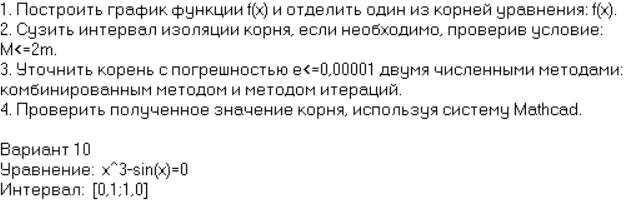

In [1]:

#  Условия задачи

import numpy as np
import matplotlib.pyplot as plt

def function(x):
    return x**3 - np.sin(x)

def proizvodnaya(x):
    return 3*x**2 - np.cos(x)

def proizvodnaya2(x):
    return 6*x + np.sin(x)

a=0.1 #начало
b=1.0 #конец
i=100 #делений

e=0.00001 #допустимая погрешность

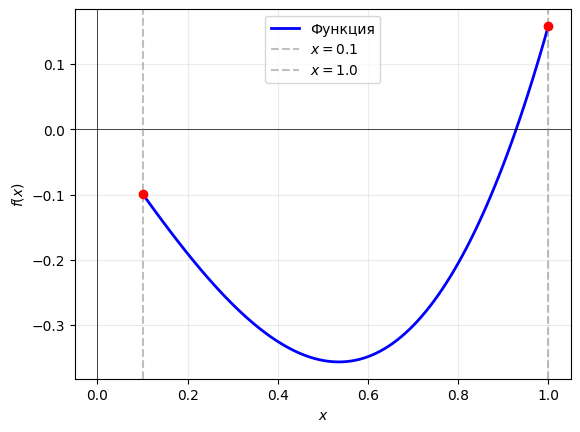

In [ ]:
 # 1) Построим график функции
def draw(it):
    x=np.linspace(a,b,i)
    y=function(x)
    fa=function(a)
    fb=function(b)
    plt.Figure(figsize=(10,6))
    if it==1:
        plt.plot(x,y,'b-',label="Функция",linewidth=2) # сама функция
        plt.axhline(0, color='k', linestyle='-', linewidth=0.5)  # ось X
        plt.axvline(a, color="gray", linestyle='--', alpha=0.5, label=f"$x = {a}$")
        plt.axvline(b, color="gray", linestyle='--', alpha=0.5, label=f"$x = {b}$")
        plt.legend()
    else:
        plt.plot(x,y,'b-',linewidth=2) # сама функция
        plt.axhline(0, color='k', linestyle='-', linewidth=0.5)  # ось X
        plt.axvline(a, color="gray", linestyle='--', alpha=0.5)
        plt.axvline(b, color="gray", linestyle='--', alpha=0.5)
    plt.plot(a,fa,"ro",)
    plt.plot(b,fb,"ro",)
    plt.axvline(0, color='k', linestyle='-', linewidth=0.5)  # ось Y
    plt.grid(True, alpha=0.25)
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")

draw(1)

In [3]:
x=np.linspace(a,b,i)
y=function(x)
fa=function(a)
fb=function(b)
# Уточним область корня
for i in range(len(y) - 1):
        pairs=[]
        y1, y2 = y[i], y[i + 1]
        # Если знаки разные: произведение отрицательно -> знак меняется, корень где то между
        if y1 * y2 < 0:
            print(f"Уточнённая область корня \n от \n {x[i]} (f(x)={y1}) \n до \n {x[i+1]} (f(x)={y2})")

# xzxzxz
# a=x[i]
# b=x[i+1]

Уточнённая область корня 
 от 
 0.9272727272727272 (f(x)=-0.002685228125175576) 
 до 
 0.9363636363636363 (f(x)=0.015573886261703751)


Неподвижная точка-b(1.0)


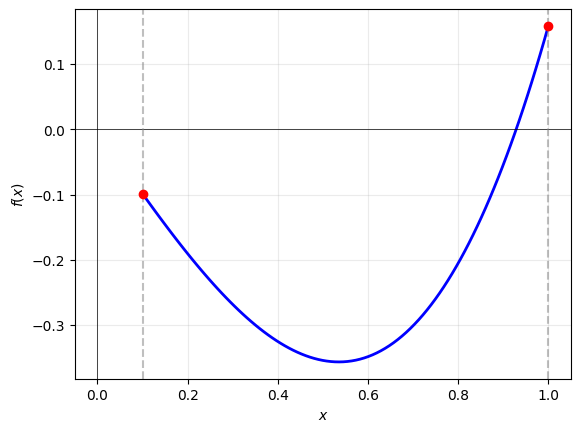

C:\Temp\ipykernel_9648\3103492756.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


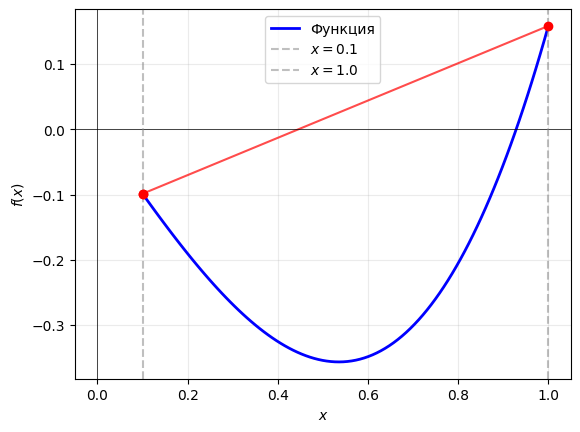

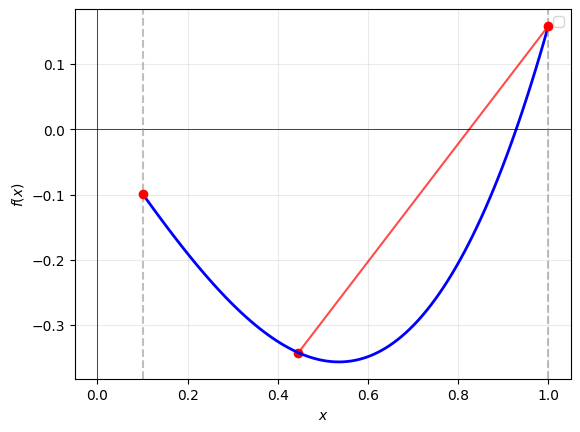

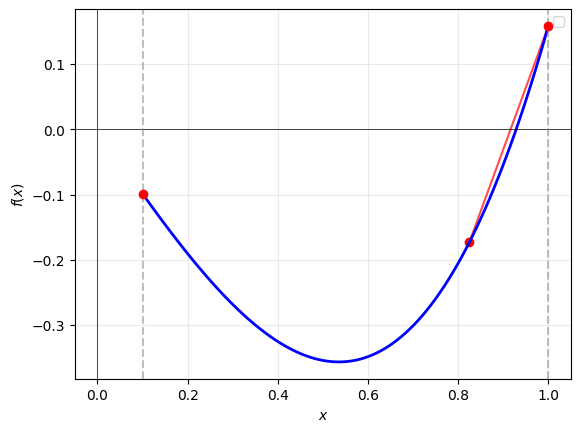

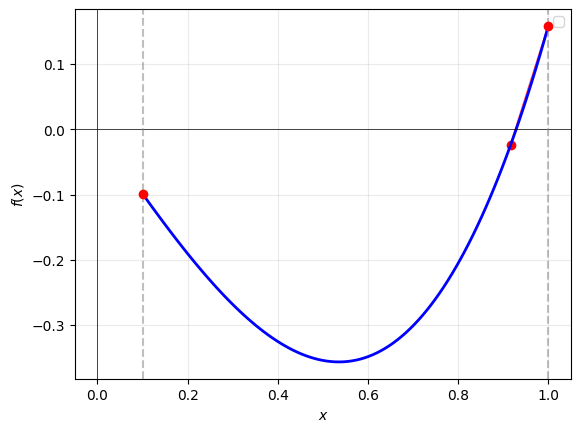

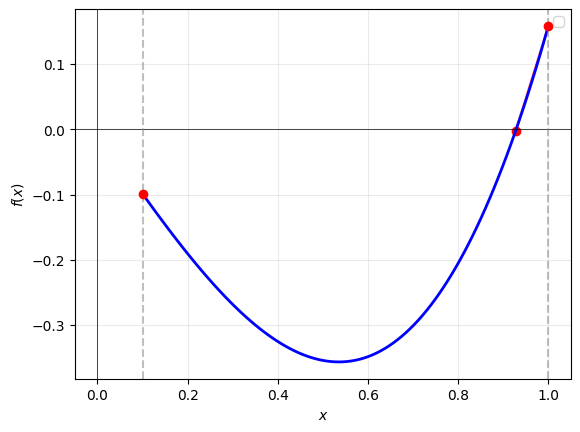

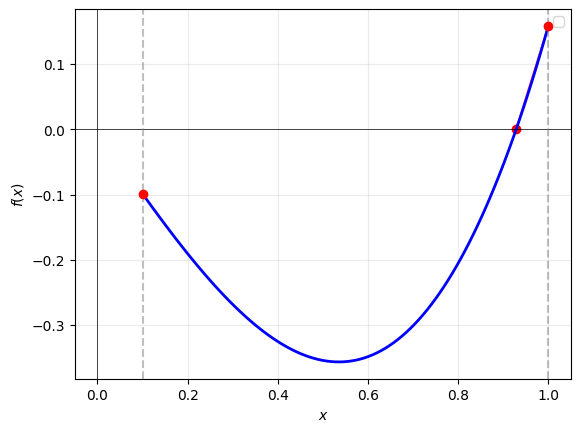

Корень найден: x = 0.92862479 (итерация 7)


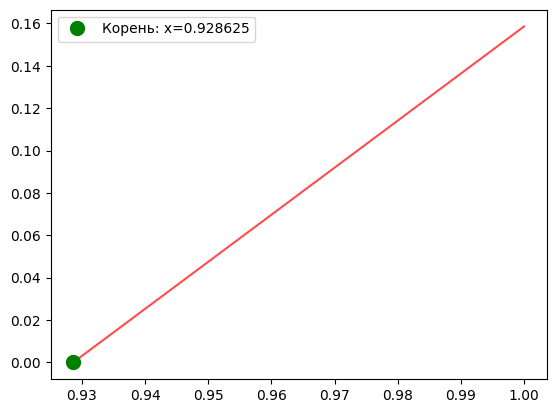

In [ ]:
# Метод хорд
# Определим формулу:



def chord_solution(sw):
    iters = 22  # Кол-ва итераций

    fa = function(a)
    fb = function(b)

    f2a = proizvodnaya2(a)
    f2b = proizvodnaya2(b)


    if (fa * f2a) >= 0:
        fix_x = a
        mov_x = b
        fix_f = fa
        print(f"Неподвижная точка-a({a})")
    elif (fb * f2b) >= 0:
        fix_x = b
        mov_x = a
        fix_f = fb
        print(f"Неподвижная точка-b({b})")
    else:
        print("Ваще хз")
    curr_x = mov_x

    for n in range(iters):
        curr_fx = function(curr_x)

        # Вычисляем h_n и следующее приближение
        if fix_x== a:
            h = curr_fx * (curr_x - a) / (curr_fx - fix_f)
        else:  # fixed_x == b
            h = curr_fx * (b - curr_x) / (fix_f - curr_fx)

        next_x = curr_x - h
        draw(n)
        if sw==1:
            plt.show()
        plt.legend()
        # Рисуем хорду (отрезок между (fixed_x, fix_f) и (curr_x, curr_fx))
        plt.plot([fix_x, curr_x], [fix_f, curr_fx],
                'r-', linewidth=1.5, alpha=0.7)
        plt.plot(curr_x, curr_fx, 'ro', markersize=6)  # текущая точка

        # Проверка точности
        if abs(function(next_x)) < e:
            plt.plot(next_x, 0, 'go', markersize=10, label=f'Корень: x={next_x:.6f}')
            print(f"Корень найден: x = {next_x:.8f} (итерация {n+1})")
            break


        curr_x = next_x  # обновляем текущую точку
    plt.legend()

chord_solution(1)
